<a href="https://colab.research.google.com/github/bpickett14/AdvancedStatisticalMethods/blob/main/WrittenReportChapter4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Brenna Pickett Bunderson - Written Report 4

In [ ]:
install.packages('Sleuth3')
library('Sleuth3')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
head(ex0430)
attach(ex0430)

,PreTreatment,Sunscreen
,<int>,<int>
1,30,120
2,45,240
3,180,480
4,15,150
5,200,480
6,20,270


#Introduction: Describe the Data and Present the Question
The dataset ex0430 from the Sleuth3 package contains measurements of tolerance to sunlight (in minutes) for 13 patients, recorded both prior to and after treatment with a sunscreen. The variable PreTreatment records the sunlight tolerance before applying the sunscreen, while Sunscreen records the tolerance after applying sunscreen. The purpose of the dataset is to evaluate whether the sunscreen increases the amount of time patients can *safely* tolerate sunlight. It raises the research question:

*Does the sunscreen significantly improve sunlight tolerance in these patients?*

Because each patient is measured before and after treatment, this is a paired data problem, suitable for analysis using a paired t-test or a nonparametric alternative if assumptions do not hold.

#Graphical Analysis

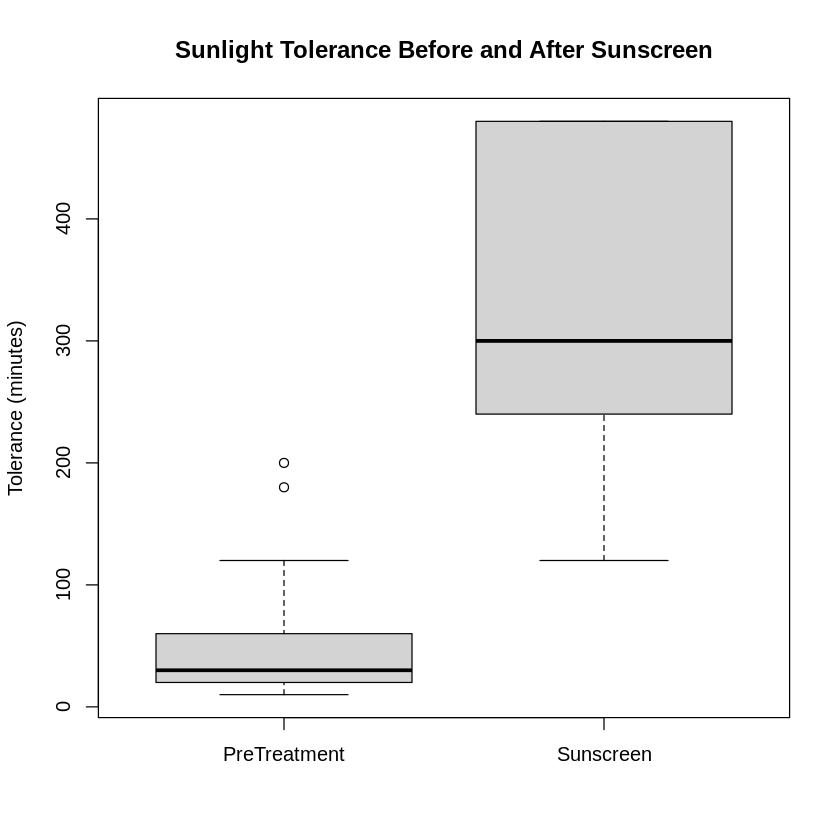

In [ ]:
boxplot(PreTreatment, Sunscreen, names = c("PreTreatment", "Sunscreen"), main = "Sunlight Tolerance Before and After Sunscreen", ylab = "Tolerance (minutes)")

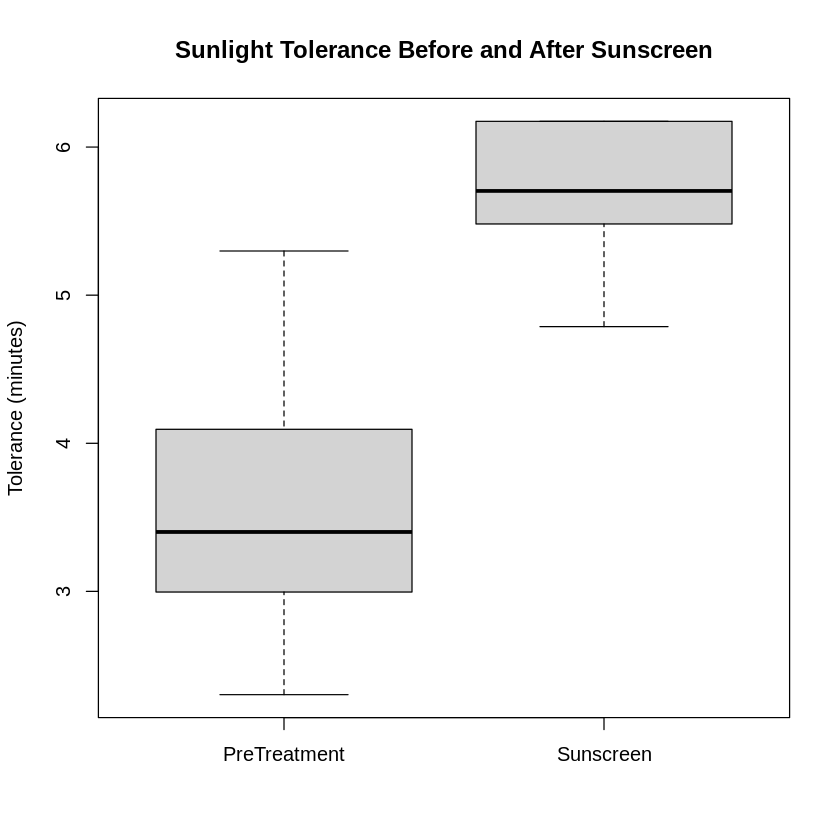

In [ ]:
boxplot(log(PreTreatment), log(Sunscreen), names = c("PreTreatment", "Sunscreen"), main = "Sunlight Tolerance Before and After Sunscreen", ylab = "Tolerance (minutes)")

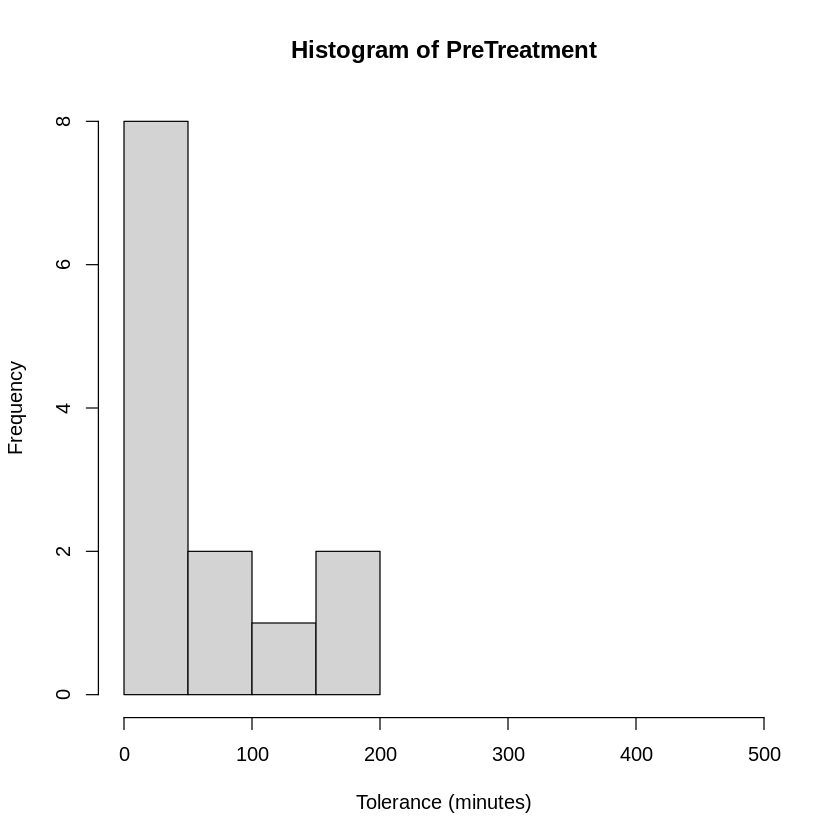

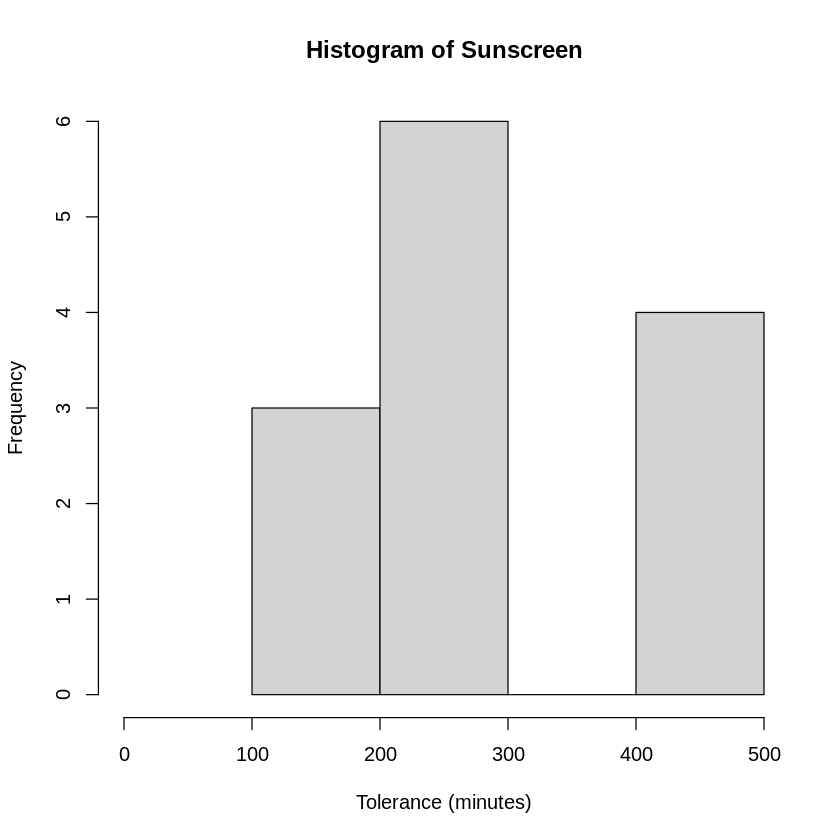

In [ ]:
hist(PreTreatment, main = "Histogram of PreTreatment", xlab = "Tolerance (minutes)", xlim = c(0, 500))
hist(Sunscreen, main = "Histogram of Sunscreen", xlab = "Tolerance (minutes)", xlim = c(0, 500))

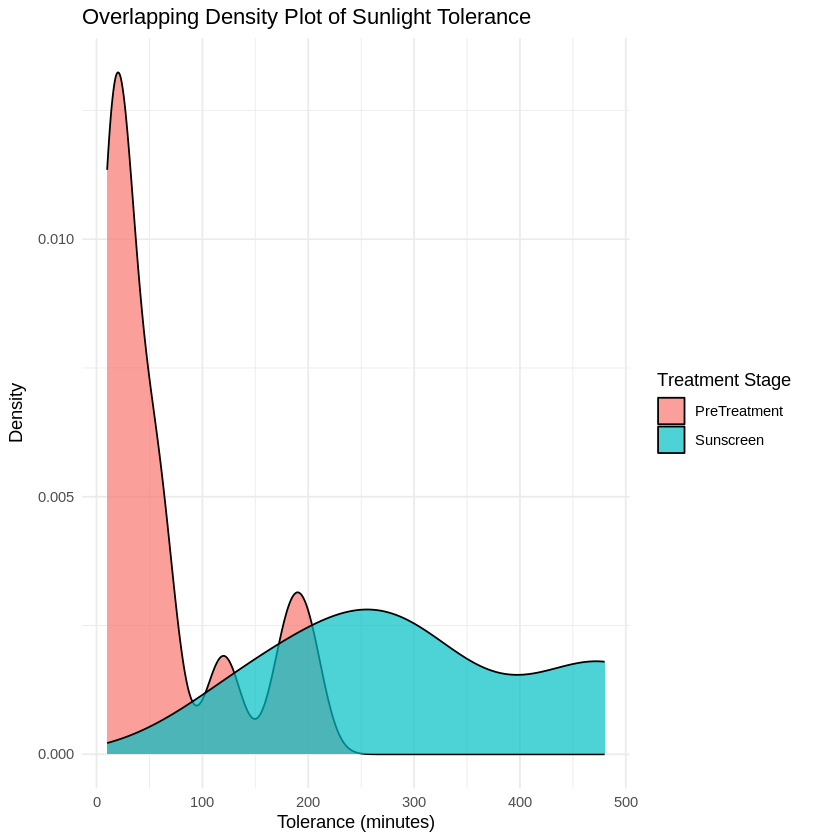

In [ ]:
if (!requireNamespace("ggplot2", quietly = TRUE)) {
  install.packages("ggplot2")
}
library(ggplot2)

# Reshape data to long format for ggplot2
df_long <- data.frame(
  Tolerance = c(PreTreatment, Sunscreen),
  Type = factor(c(rep("PreTreatment", length(PreTreatment)), rep("Sunscreen", length(Sunscreen))))
)

# Create overlapping density plot
ggplot(df_long, aes(x = Tolerance, fill = Type)) +
  geom_density(alpha = 0.7) +
  labs(title = "Overlapping Density Plot of Sunlight Tolerance",
       x = "Tolerance (minutes)",
       y = "Density",
       fill = "Treatment Stage") +
  theme_minimal()


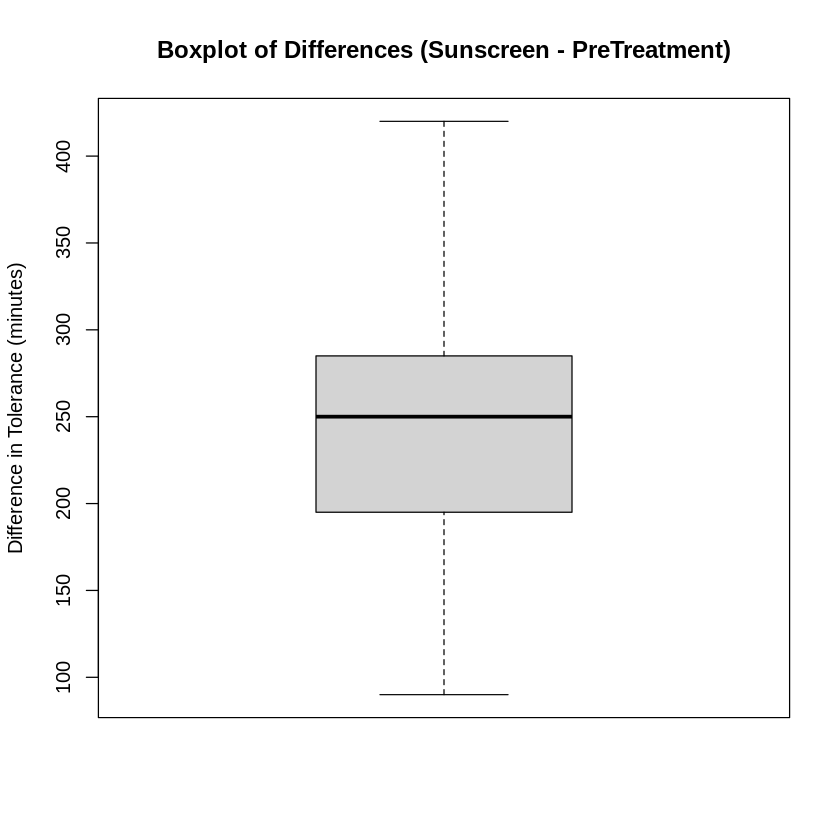

In [ ]:
boxplot(differences, main = "Boxplot of Differences (Sunscreen - PreTreatment)",
        ylab = "Difference in Tolerance (minutes)", col = "lightgray")
abline(h = 0, col = "red", lty = 2)

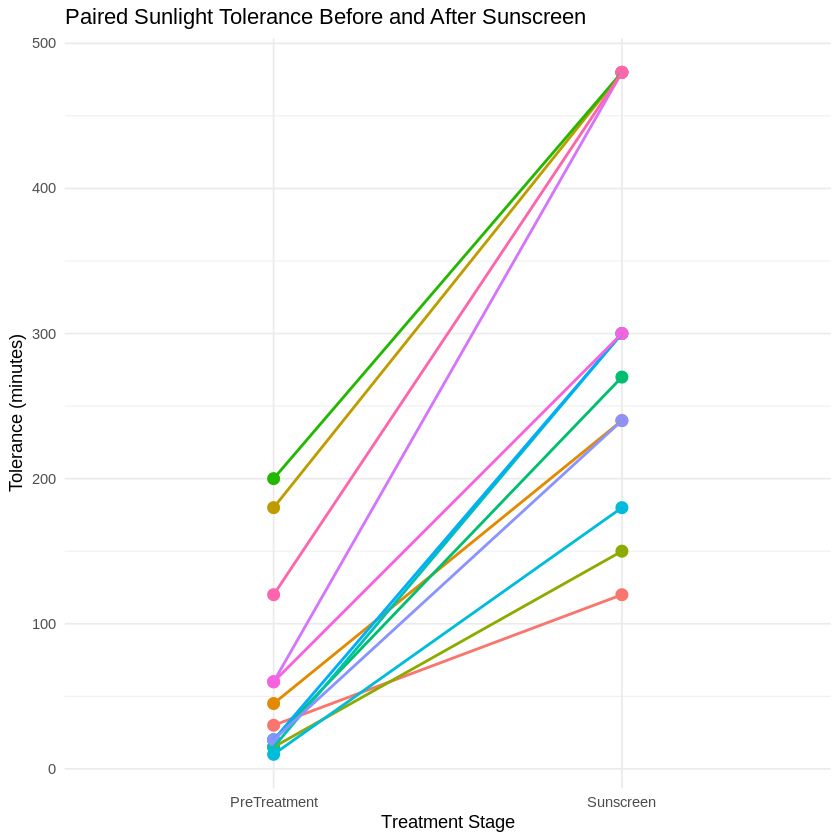

In [ ]:
if (!requireNamespace("ggplot2", quietly = TRUE)) {
  install.packages("ggplot2")
}
library(ggplot2)

# Create a data frame for plotting, including a PatientID
patient_data <- data.frame(
  PatientID = factor(1:length(PreTreatment)), # Assign a unique ID for each patient
  PreTreatment = PreTreatment,
  Sunscreen = Sunscreen
)

# Create the paired scatterplot
ggplot(patient_data) +
  geom_point(aes(x = "PreTreatment", y = PreTreatment, color = PatientID), size = 3) +
  geom_point(aes(x = "Sunscreen", y = Sunscreen, color = PatientID), size = 3) +
  geom_segment(aes(x = "PreTreatment", xend = "Sunscreen", y = PreTreatment, yend = Sunscreen, color = PatientID),
               linetype = "solid", linewidth = 0.8) +
  labs(title = "Paired Sunlight Tolerance Before and After Sunscreen",
       y = "Tolerance (minutes)",
       x = "Treatment Stage") +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend for clarity as each patient has a color

#Assumptions
###Independence
Since the influence of sunscreen (or lack thereof) on one patient doesn't affect the influence of another's, I would reasonably say this is independent. That only holds true as long as the patient's data is paired. Otherwise, the data would become dependent.

###Normality
Well, we looked at the normality assumption a little with the box plots, but let's do the Shapiro Test.

In [ ]:
differences <- Sunscreen - PreTreatment
shapiro.test(differences)


	Shapiro-Wilk normality test

data:  differences
W = 0.98534, p-value = 0.996


Well, seeing as the null hypothesis for the Shapiro-Wilk test is that the distribution is normal, we fail to reject the null hypothesis and conclude that the distribution is normal.

##Homogeneity (Variances)
For paired data, inference is based on the distribution of the within-subject differences rather than a comparison of two independent groups. As a result, equal variance assumptions are not required. To avoid reliance on normality assumptions given the small sample size, a sign-flipping permutation test was used, but here is an attempt at testing equal variance just because it feels wrong not to include it.

In [ ]:
install.packages("lawstat")
library(lawstat)

# Combine the data into a single vector
combined_data <- c(PreTreatment, Sunscreen)

# Create a grouping factor
group_factor <- factor(c(rep("PreTreatment", length(PreTreatment)), rep("Sunscreen", length(Sunscreen))))

# Perform Levene's Test
levene.test(combined_data, group_factor, location = "median")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Kendall’, ‘mvtnorm’, ‘Rdpack’





	Modified robust Brown-Forsythe Levene-type test based on the absolute
	deviations from the median

data:  combined_data
Test Statistic = 4.7366, p-value = 0.0396


The null hypothesis of the Levene's Test is that the variances are equal. With a p-value of 0.0396, we are going to have to reject the null. The variances are not equal. Let's check if they are when we log transform the data.

In [ ]:
# Log transform the data
log_PreTreatment <- log(PreTreatment)
log_Sunscreen <- log(Sunscreen)

# Combine the log-transformed data into a single vector
combined_log_data <- c(log_PreTreatment, log_Sunscreen)

# Create a grouping factor
group_factor_log <- factor(c(rep("PreTreatment", length(log_PreTreatment)), rep("Sunscreen", length(log_Sunscreen))))

# Perform Levene's Test on log-transformed data
levene.test(combined_log_data, group_factor_log, location = "median")


	Modified robust Brown-Forsythe Levene-type test based on the absolute
	deviations from the median

data:  combined_log_data
Test Statistic = 6.808, p-value = 0.01538


That's even worse! We will have to use either the Wilcoxon signed-rank test or a Permutation test instead, since the assumptions of the paired T-Test are not met. Since the Rank Sum Test cannot be used for paired data, I think the permutation test makes more sense. Let's try it.

In [ ]:
differences <- Sunscreen - PreTreatment

# 1. Calculate the observed differences (already done in previous cell, re-executing for completeness)
# 2. Calculate the observed mean difference
observed_mean_difference <- mean(differences)

# 3. Initialize an empty vector to store the permuted mean differences
permuted_means <- c()

# 4. Set the number of permutations
num_permutations <- 10000

# 5. Loop num_permutations times to perform the permutation test
for (i in 1:num_permutations) {
  # a. Create a vector of random signs (either -1 or 1)
  random_signs <- sample(c(-1, 1), length(differences), replace = TRUE)

  # b. Multiply the observed_differences by these random signs
  permuted_diffs <- differences * random_signs

  # c. Calculate the mean of these permuted_differences
  permuted_mean <- mean(permuted_diffs)

  # d. Append this mean to the permuted_means vector
  permuted_means <- c(permuted_means, permuted_mean)
}

# 6. Calculate the p-value
p_value <- sum(abs(permuted_means) >= abs(observed_mean_difference)) / num_permutations

cat("Observed Mean Difference:", observed_mean_difference, "\n")
cat("P-value from Permutation Test:", p_value, "\n")

Observed Mean Difference: 248.0769 
P-value from Permutation Test: 2e-04 


#Statistical Conclusion
The sign-flipping permutation test yielded an observed mean difference of approximately 248.08 minutes in sunlight tolerance after sunscreen application, with a p-value of 0.0002. Given such a small p-value (much less than the conventional significance level of 0.05), we reject the null hypothesis that there is no difference in sunlight tolerance before and after sunscreen application. This indicates strong convincing statistical evidence that the sunscreen significantly increases patients' tolerance to sunlight.

#Scope of Inference
This study was a designed experiment, as patients received both pre-treatment and post-treatment measurements, allowing for a paired comparison. Since the treatment (sunscreen application) was applied and its effect measured, we can infer causation: the sunscreen causes an increase in sunlight tolerance. However, the study involved only 13 patients, which is a very small sample size. Therefore, while the results are statistically significant for this sample, the ability to generalize these findings to a broader population is limited. The data provides convincing evidence for the effectiveness of the sunscreen within this small group, but further research with a larger, more diverse sample would be needed to confidently apply these conclusions to a wider population of patients.

In [ ]:
detach(ex0430)